In [1]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [185]:
pi = np.pi

sim = Sim(use_complex=True)


sim.add_param('sqrtka_ext', np.sqrt(1e6*2*pi)) # in MHz
sim.add_param('ka_int', 1e6*2*pi) # in MHz
sim.add_param('g4', 0e6 * 2 * np.pi)
sim.add_param('g2eff', 0e6 * 2 * np.pi)
sim.add_param('amplR', 2000000)
sim.add_param('wa', 5.0e9 * 2*pi)  #this simulates a slow dephasing effect
sim.add_paramsweep('wR', 4.8e9 * 2 * np.pi, 5.2e9 * 2 * np.pi, 101, is_excitation=True)
sim.add_param('rampR', 0.5e-9)
sim.add_param('startR1', 5e-9)
sim.add_param('stopR1', 6e-9)
sim.add_param('startR2', 60e-9)
sim.add_param('stopR2', 90e-9)
sim.add_param('phaseR', pi)
sim.add_paramsweep('phaseIC', 0, 2*pi, 101)

Rpulse1 = sim.make_pulse('-wR', 'amplR', 'phaseR', 'startR1', 'stopR1', 'rampR')
Rpulse2 = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR2', 'stopR2', 'rampR')

ain_pulses = sim.make_pulse_sequence([Rpulse1, Rpulse2])

sim.add_EOM('ain', ain_pulses)

sim.add_EOM('a', '-1j*wa*a - ain*sqrtka_ext - 1j*g2eff*conjugate(a) - (sqrtka_ext**2 + ka_int)/2*a - 1j*a*g4*abs(a)**2 ', IC_str='cos(phaseIC)')
sim.set_solve_type('decimate')

sim.specify_time(20, 50, d_factor=1)

sim.validate()

ValueError: operands could not be broadcast together with shapes (101,51) (101,) 

In [180]:
ain_pulses

'amplR*-wR*exp(-1j*(-wR*t +phaseR))*(tanh((t-startR1)/rampR)-tanh((t-stopR1)/rampR)) + amplR*wR*exp(-1j*(wR*t +phaseR))*(tanh((t-startR2)/rampR)-tanh((t-stopR2)/rampR))'

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


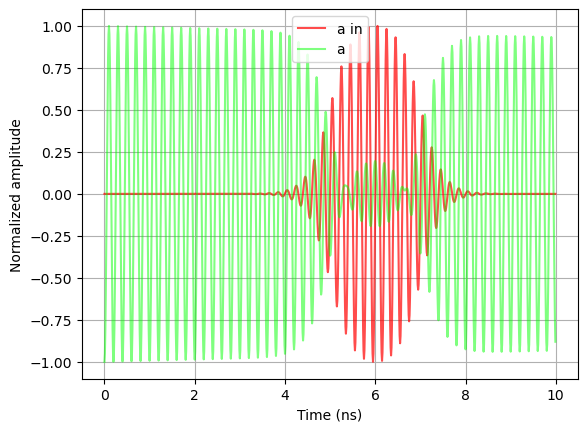

In [181]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:]),color=(0,1,0,0.5),label='a')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

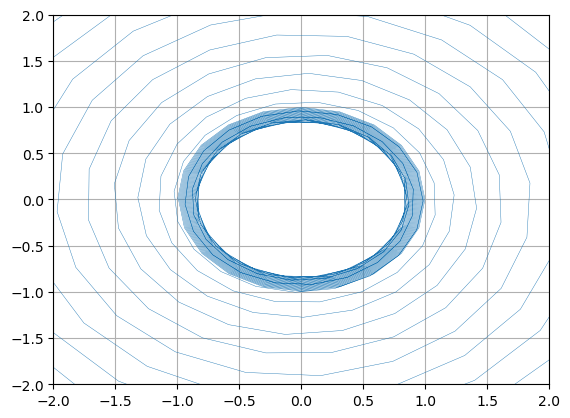

In [88]:
plt.clf()
plt.plot(x[2,:], x[3,:], linewidth=0.3)
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.grid()
plt.show()

In [8]:
I, Q, t = sim.solve()

Simulation validation success!


AttributeError: 'Sim' object has no attribute 'ICs'

In [59]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

ain = Id[0,:]+1j*Qd[0,:]
a = Id[2,:]+1j*Qd[2,:]

aout = ain + sim.param_dict['sqrtka_ext']*a

C:\Users\boris\AppData\Local\Temp\ipykernel_43272\4253816078.py:1: RuntimeWarning: invalid value encountered in divide
  S11 = (aout/ain)[:,:,-1]


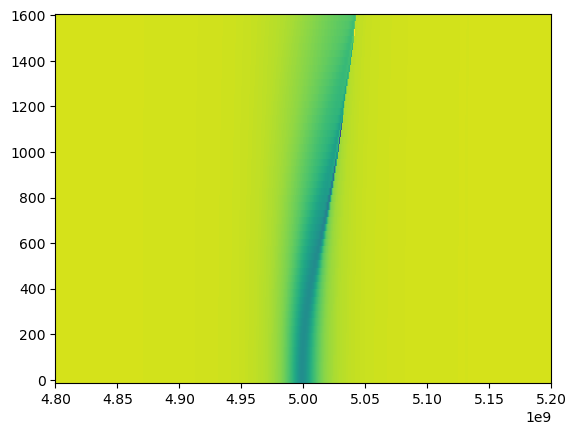

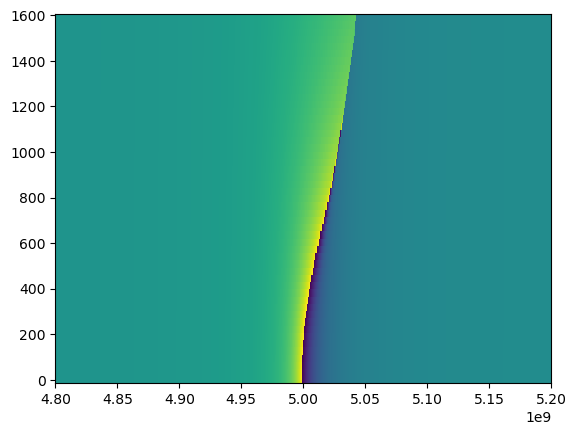

In [60]:
S11 = (aout/ain)[:,:,-1]

wR = sim.paramsweep_dict['wR']/(2*np.pi)
amplR = sim.paramsweep_dict['amplR']/(2*np.pi)

plt.pcolor(wR, amplR, np.abs(S11))
plt.show()
plt.pcolor(wR, amplR, np.angle(S11))
plt.show()